# RAG System for Finance Domain - Complete Architecture Guide

## 🎯 What We're Building

A **Retrieval-Augmented Generation (RAG)** system for financial Q&A. This pipeline:
1. **Retrieves** relevant documents from a large financial dataset
2. **Augments** an LLM prompt with retrieved context
3. **Generates** accurate answers grounded in the retrieved information
4. **Evaluates** answer quality using 4 TRACe metrics

---

## 📊 Pipeline Overview

```
User Question
    ↓
[1] Chunk context into passages (TextChunker)
    ↓
[2] Convert text to embeddings (Embedder)
    ↓
[3] Store embeddings in vector database (FAISS)
    ↓
[4] Retrieve relevant passages (Hybrid Retriever)
    ↓
[5] Generate answer using LLM (Ollama Generator)
    ↓
[6] Evaluate quality (TRACe Evaluator)
    ↓
Answer + Scores
```

---

## 🔧 Key Components Explained

### **1. TextChunker** - Break documents into manageable pieces
- **Why?** Long documents don't fit in LLM context window. We split into ~512 token chunks
- **Method:** Sliding window (overlap prevents losing context at boundaries)
- **Input:** Raw financial text (~12KB document)
- **Output:** List of chunks (13 chunks per document)
- **Example:** [chunk1: "The company reported...", chunk2: "Q4 earnings were..."]

### **2. Embedder** - Convert text to vectors
- **Model:** BAAI/bge-large-en-v1.5 (1024-dimensional)
- **What it does:** Transforms text → 1024-dim vector that captures meaning
- **Why?** Vectors enable semantic search (find similar text without keyword matching)
- **Query prefix:** "Represent this sentence for searching relevant passages: {query}"
- **Device:** GPU (CUDA) for 2-3x faster processing

### **3. FAISS Vector Store** - Search engine for embeddings
- **What it does:** Stores vectors and finds most similar ones
- **Method:** IndexFlatIP (inner product = cosine similarity on normalized vectors)
- **Speed:** Sub-millisecond search even with millions of embeddings
- **Example:** Query "What's the stock price?" → Find top-5 most similar documents

### **4. Hybrid Retriever** - Combine keyword + semantic search
- **BM25 retriever:** Traditional keyword matching (TF-IDF) - good for named entities, numbers
- **Dense retriever:** Semantic similarity using embeddings - good for concepts
- **Hybrid:** Reciprocal Rank Fusion (RRF) combines both rankings
- **Weighting:** 50% BM25 + 50% dense embeddings
- **Output:** Top 5 most relevant chunks for your question

### **5. Ollama Generator** - LLM that generates answers
- **Model:** Qwen2.5-14B (14 billion parameters)
- **Temperature:** 0.1 (low = less random, more factual)
- **Context window:** 4096 tokens (max input length)
- **System prompt:** Enforces grounding in context (no hallucination)
- **Device:** CPU (local machine, no API calls needed)

### **6. TRACe Evaluator** - Score answer quality
- **Metric 1: Context Relevance** → Are retrieved passages relevant to question?
- **Metric 2: Context Utilization** → Did LLM actually use the retrieved context?
- **Metric 3: Completeness** → Does answer cover all information in context?
- **Metric 4: Adherence** → Is answer grounded (no hallucination)?
- **Score range:** 0-1 (1 = perfect)
- **Method:** NLI (Natural Language Inference) cross-encoder model

---

## 📈 Data Flow Example

### Input Question:
```
"What percent of total obligations in 2014 are from purchase commitments?"
```

### Step 1: Chunking
```
Context: ~8000 tokens financial document
↓
13 chunks (~512 tokens each, 64-token overlap)
```

### Step 2: Retrieval
```
Find 5 chunks most similar to question
• Chunk 1: "...contractual obligations... $140M, $34M, $7M, $20M..."
• Chunk 2: "...other purchase commitments... $20M..."
• etc.
```

### Step 3: Generation
```
System: "Answer using only the context provided"
Context: [5 retrieved chunks]
Question: "What percent of total obligations..."
LLM: "Total 2014 obligations = $201M. Purchase commitments = $20M. 
      Percentage = (20/201) × 100 = 9.95%"
```

### Step 4: Evaluation
```
context_relevance: 1.0 ✓ (all chunks relevant)
context_utilization: 0.8 ✓ (LLM used some context)
completeness: 0.9 ✓ (covered key info)
adherence: 1.0 ✓ (no hallucination)
avg_trace: 0.925
```

---

## ⚙️ Configuration Parameters

| Parameter | Value | Why? |
|-----------|-------|------|
| **Embedding Model** | BAAI/bge-large-en-v1.5 | Finance domain optimized, 1024-dim |
| **Chunk Size** | 512 tokens | Fits in context window |
| **Chunk Overlap** | 64 tokens | Prevents losing context at boundaries |
| **Top-k Retrieval** | 5 chunks | Balance quality vs LLM input length |
| **Hybrid Weight** | 0.5 BM25 + 0.5 Dense | Equal importance both methods |
| **LLM Temperature** | 0.1 | Low = factual, high = creative |
| **Device** | GPU (CUDA) | 2-3x faster than CPU |

---

## 💾 Data Source

**Dataset:** RAGBench FinQA (from Hugging Face)
- **Domain:** Financial Q&A
- **Full Size:** 12,502 questions + context
- **Current Sample:** 50 questions (for development speed)
- **Can change to:** 12,502 (set `SAMPLE_SIZE = None`)

---

## 📊 What Each Cell Does

| Cell # | Step | Action |
|--------|------|--------|
| 1-2 | Setup | Intro and badges |
| 3 | Libraries | Import all dependencies |
| 4 | Config | Set up paths and environment |
| 5 | Load Data | Download FinQA dataset from Hugging Face |
| 6 | EDA | Explore data distribution |
| 7 | Chunker | Define TextChunker class |
| 8 | Embedder | Define Embedder class + FAISS store |
| 9 | Retrievers | Define BM25, Dense, Hybrid retrievers |
| 10 | Generator | Define Ollama LLM wrapper |
| 11 | Evaluator | Define TRACe evaluation metrics |
| 12 | Smoke Test | Run 1 sample end-to-end (validation) |
| 13 | Baseline | Run 50 samples and collect results |
| 14 | Comparison | Compare our scores vs ground truth |
| 15+ | Experiments | RGB/Ablation/Analysis (not run yet) |

---

## 🔍 Key Terms Glossary

| Term | Meaning |
|------|---------|
| **RAG** | Retrieval-Augmented Generation |
| **Embedding** | Vector representation of text (captures meaning) |
| **FAISS** | Facebook AI Similarity Search (vector database) |
| **BM25** | Traditional TF-IDF ranking algorithm |
| **Hybrid** | Combines multiple retrieval methods |
| **TRACe** | Truth-grounded Reasoning And Context Evaluation |
| **NLI** | Natural Language Inference (entailment scoring) |
| **LLM** | Large Language Model (Qwen2.5 in our case) |
| **Grounding** | Answer supported by context (not hallucinated) |
| **Token** | ~4 characters of text (basic unit) |

---

## 🚀 Next Steps

1. **Baseline:** Run 50-sample pipeline (Step 13)
2. **Scale:** Increase to 12,502 samples for full evaluation
3. **Optimize:** Fine-tune chunk size, retrieval k, temperature
4. **Evaluate:** Compare our results vs GPT-4 benchmark scores

---
## Phase 0 — Setup & EDA

## Quick Navigation

**🎯 Main Pipeline:**
- Step 1.1: TextChunker (Chunk long documents)
- Step 1.2: Embedder (Convert text to vectors)
- Step 1.3: Retrievers (Find relevant chunks)
- Step 1.4: Generator (Generate answers with LLM)
- Step 1.5: Evaluator (Score answer quality)
- Step 1.6: Smoke Test (Test 1 sample)
- Step 1.7: Baseline (Run 50 samples)
- Step 1.8: Comparison (vs ground truth)

**📊 Experiments:**
- Phase 2: RGB (Robustness tests)
- Phase 3: Ablation (Component analysis)
- Phase 4: Strategy matrix

---

## The 5-Minute Version

| # | Component | What It Does | Input | Output |
|---|-----------|------|--------|---------|
| 1 | **Chunker** | Break 10KB document into 512-token pieces | Long text | 13 chunks |
| 2 | **Embedder** | Convert text → 1024-dim vector | Text | Vector (meaning-capture) |
| 3 | **Retriever** | Find top-5 most relevant chunks | Query + vectors | Top-5 chunks |
| 4 | **Generator** | Create answer using LLM + context | Question + chunks | Answer text |
| 5 | **Evaluator** | Score 4 metrics (adherence, relevance, etc) | Q + Context + Answer | Scores (0-1) |

---

## 🎓 Beginner's Guide - What Are We Really Doing?

### The Problem We're Solving

**Without RAG:** You ask ChatGPT a question about a company → ChatGPT makes up an answer (hallucination)

**With RAG:** You give ChatGPT a question + relevant documents → ChatGPT gives an accurate answer grounded in those documents

### A Real-World Example

**Question:** "What was Apple's Q4 2019 net revenue?"

**Step 1: Chunking** (Prepare documents)
- Take a 20-page financial report
- Split into 13 chunks (~512 tokens each)
- This keeps each chunk small enough for the LLM

**Step 2: Embedding** (Create searchable vectors)
- Convert each chunk to a 1024-dimensional vector
- Vector = mathematical representation of meaning
- Similar text → similar vectors

**Step 3: Retrieval** (Find relevant chunks)
- User asks: "What was Q4 2019 net revenue?"
- System finds top-5 chunks most similar to this question
- Retrieved: "Apple reported net revenue of $2.74 billion in Q4 2019..."

**Step 4: Generation** (Generate answer)
- Give LLM the question + retrieved chunks
- LLM reads chunks and writes: "According to the financial report, Apple's Q4 2019 net revenue was $2.74 billion."

**Step 5: Evaluation** (Score quality)
- Did LLM use the context? ✓ (context_utilization = 1.0)
- Is the answer grounded? ✓ (adherence = 1.0)
- Did we retrieve relevant chunks? ✓ (context_relevance = 1.0)
- Score: 1.0 / 1.0 (perfect!)

---

### Why Each Component Matters

| Component | Why It Exists | Without It |
|-----------|---------------|-----------|
| **Chunker** | LLMs can't process entire 20KB documents | Lose information, too large |
| **Embedder** | Need to find similar documents semantically, not just keywords | Can only do keyword search, bad at concepts |
| **Retriever** | Must find TOP 5 most relevant chunks from thousands | Takes too long, outdated info |
| **Generator** | Creates coherent answer from chunks | Just returns raw chunks |
| **Evaluator** | Measures if system actually works | Don't know if answers are good |

---

### Dataset Walkthrough

**What we have:** 12,502 financial Q&A samples from RAGBench

**Each sample contains:**
```python
{
  "question": "What was Q4 2019 revenue?",
  "documents": ["Apple Inc. annual report... $2.74B...", "Financial overview..."],  # Pre-retrieved chunks
  "response": "Apple's Q4 2019 net revenue was $2.74 billion",  # Ground truth answer
  "gpt3_adherence": 1.0,  # Score: is answer grounded? (1.0 = perfect)
  "gpt3_context_relevance": 0.95,  # Score: are chunks relevant?
  "gpt35_utilization": 0.85,  # Score: did LLM use context?
  "completeness_score": 0.9,  # Score: does answer cover all info?
}
```

**What we're doing:**
1. Take the `question` and `documents`
2. Run through OUR pipeline (chunker → embedder → retriever → generator → evaluator)
3. Compare OUR scores against the ground truth scores
4. Measure: "How close are we to GPT-4?"

---

### Understanding the Code Structure

```
notebook cells are organized as:

SETUP (cells 1-3)
├─ Intro & badges
├─ Load libraries
└─ Configure environment

DATA (cells 4-9)
├─ Load FinQA dataset
├─ Explore data distribution
├─ Compare across domains
└─ Show sample rows

BUILDING COMPONENTS (cells 10-15)
├─ TextChunker class
├─ Embedder + FAISS classes
├─ BM25/Dense/Hybrid Retrievers
├─ Ollama Generator
└─ TRACe Evaluator

PIPELINE (cells 16-20)
├─ Smoke test (1 sample)
├─ Baseline run (50 samples)
├─ Results comparison
└─ Visualizations

EXPERIMENTS (cells 21+)
├─ Phase 2: RGB robustness
├─ Phase 3: Ablation studies
└─ Phase 4: Multi-domain analysis
```

---

### Key Parameters You Can Tweak

```python
# In data loading cell:
SAMPLE_SIZE = 50        # ← Change to None for full 12,502 samples

# In retriever:
top_k = 5               # How many chunks to retrieve (1-10)

# In embedder:
batch_size = 32         # How many chunks to encode at once (higher = faster but more memory)

# In generator:
temperature = 0.1       # 0.1 = factual, 0.9 = creative

# In evaluator:
threshold = 0.5         # Score above 0.5 counts as "relevant"
```

---

### Running the Pipeline

**For quick testing (50 samples, ~15 minutes):**
```python
# Just run cells in order. Default SAMPLE_SIZE = 50
```

**For full evaluation (12,502 samples, ~6-8 hours):**
```python
# Change in data loading cell:
SAMPLE_SIZE = None
# Then run cells
```

---

### Interpreting Results

When you see output like:
```
context_relevance        ████████████████████  1.000
context_utilization      ░░░░░░░░░░░░░░░░░░░░  0.000
completeness             ████████░░░░░░░░░░░░  0.375
adherence                ████████████░░░░░░░░  0.600
avg_trace                ████████░░░░░░░░░░░░  0.494
```

This means:
- ✓ Retrieved chunks are relevant (1.0 = perfect)
- ✗ LLM didn't use retrieved context (0.0 = bad)
- ~ Answer partially covers the info (0.375 = 38%)
- ~ Answer is partially grounded, has some hallucination (0.6 = 60%)
- ~ Overall: about 49% quality (vs GPT-4 benchmark)

**Good scores:** > 0.8 on all metrics  
**Acceptable scores:** > 0.6 on all metrics  
**Needs work:** < 0.6 on any metric

### Step 0.1 — Install Dependencies

In [1]:
# ✅ KAGGLE-COMPATIBLE INSTALL CELL
# Run once. No restart needed on Kaggle — packages install into the session.
import subprocess, sys

# Detect GPU before torch is fully loaded
try:
    import torch
    _has_gpu = torch.cuda.is_available()
except ImportError:
    _has_gpu = False

packages = [
    "datasets",
    "sentence-transformers>=3.0.0",
    "transformers>=4.40.0",
    "accelerate>=0.27.0",
    "torch",
    "rank-bm25",
    "pandas",
    "numpy",
    "tqdm",
    "matplotlib",
    "seaborn",
    "tabulate",
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

# FAISS: try faiss-gpu first, fall back to faiss-cpu.
# On Kaggle, faiss is often pre-installed; the pip 'faiss-gpu' package
# is no longer published, so we gracefully fall back.
_faiss_installed = False
if _has_gpu:
    try:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "faiss-gpu", "-q"],
            stderr=subprocess.DEVNULL,
        )
        _faiss_installed = True
    except subprocess.CalledProcessError:
        pass

if not _faiss_installed:
    try:
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "faiss-cpu", "-q"],
            stderr=subprocess.DEVNULL,
        )
        _faiss_installed = True
    except subprocess.CalledProcessError:
        pass

# Final check — import faiss to verify it's available (pre-installed on Kaggle)
import faiss
print(f"✅ All packages installed.  FAISS version: {faiss.__version__}  (GPU index support: {_has_gpu})")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 91.2 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 71.3 MB/s eta 0:00:00
✅ All packages installed.  FAISS version: 1.14.2  (GPU index support: True)


### Step 0.2 — Import Libraries

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# SETUP LOGGING — Track all pipeline operations
# ═══════════════════════════════════════════════════════════════════════════════

import logging
import sys
from datetime import datetime

# Create logs directory
import os
os.makedirs("logs", exist_ok=True)

# Configure logging with both file and console output
log_file = f"logs/rag_pipeline_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"

# Create formatter
formatter = logging.Formatter(
    '%(asctime)s | %(name)-20s | %(levelname)-8s | %(message)s',
    datefmt='%H:%M:%S'
)

# File handler
file_handler = logging.FileHandler(log_file)
file_handler.setLevel(logging.DEBUG)
file_handler.setFormatter(formatter)

# Console handler
console_handler = logging.StreamHandler(sys.stdout)
console_handler.setLevel(logging.INFO)
console_handler.setFormatter(formatter)

# Root logger
root_logger = logging.getLogger()
root_logger.setLevel(logging.DEBUG)
root_logger.addHandler(file_handler)
root_logger.addHandler(console_handler)

# Create module-specific loggers
logger = logging.getLogger('RAG_PIPELINE')
data_logger = logging.getLogger('DATA_LOADER')
chunker_logger = logging.getLogger('CHUNKER')
embedder_logger = logging.getLogger('EMBEDDER')
retriever_logger = logging.getLogger('RETRIEVER')
generator_logger = logging.getLogger('GENERATOR')
evaluator_logger = logging.getLogger('EVALUATOR')

logger.info("="*80)
logger.info("RAG PIPELINE INITIALIZED")
logger.info(f"Log file: {log_file}")
logger.info("="*80)

print("✓ Logging configured successfully")
print(f"  File: {log_file}")
print(f"  Console: INFO and above")


08:39:54 | RAG_PIPELINE         | INFO     | ================================================================================
08:39:54 | RAG_PIPELINE         | INFO     | RAG PIPELINE INITIALIZED
08:39:54 | RAG_PIPELINE         | INFO     | Log file: logs/rag_pipeline_20260606_083954.log
08:39:54 | RAG_PIPELINE         | INFO     | ================================================================================
✓ Logging configured successfully
  File: logs/rag_pipeline_20260606_083954.log
  Console: INFO and above


### Step 0.3 — Add Project Root to Path

In [3]:
import sys, os

# Kaggle working directory is /kaggle/working
# All output files will be saved here automatically
PROJECT_ROOT = "/kaggle/working"
os.makedirs(PROJECT_ROOT, exist_ok=True)
os.chdir(PROJECT_ROOT)   # Make sure relative paths resolve under /kaggle/working

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"Working directory: {os.getcwd()}")


Working directory: /kaggle/working


### Step 0.4 — Load RAGBench Dataset (FinQA domain)

In [4]:
from datasets import load_dataset
import shutil
import os

# ═══════════════════════════════════════════════════════════════════════════════
# STEP 1: LOAD FINANCIAL QA DATA FROM HUGGING FACE
# ═══════════════════════════════════════════════════════════════════════════════

"""
This section loads the RAGBench FinQA dataset (12,502 financial Q&A samples)
and prepares it for the RAG pipeline.

WHY THIS DATASET?
- FinQA: 12,502 questions about company financial reports
- Each sample has: question, context (relevant passages), ground truth answer
- Perfect for training/evaluating RAG systems on domain-specific data
"""

# Configuration: How many samples to use
DOMAIN      = "finqa"              # Financial domain dataset
SAMPLE_SIZE = 200                   # ← CHANGE TO None FOR FULL 12,502 SAMPLES
SEED        = 42                   # For reproducibility

data_logger.info(f"Data Loading Configuration: domain={DOMAIN}, sample_size={SAMPLE_SIZE}")

# ─────────────────────────────────────────────────────────────────────────────
# Clear cached data (Hugging Face sometimes caches corrupted files)
# ─────────────────────────────────────────────────────────────────────────────
cache_dir = os.path.expanduser("~/.cache/huggingface/datasets/galileo-ai___ragbench")
if os.path.exists(cache_dir):
    data_logger.info(f"Clearing cache at {cache_dir}...")
    try:
        shutil.rmtree(cache_dir)
        data_logger.info("Cache cleared successfully")
    except Exception as e:
        data_logger.warning(f"Could not clear cache: {e}")

# ─────────────────────────────────────────────────────────────────────────────
# Download dataset from Hugging Face Hub
# ─────────────────────────────────────────────────────────────────────────────
try:
    data_logger.info(f"Downloading RAGBench [{DOMAIN}] dataset...")
    # Load train split with force redownload to ensure fresh data
    ds = load_dataset(
        "galileo-ai/ragbench",           # Dataset source
        DOMAIN,                          # Use "finqa" subset
        split="train",                   # Use training split (not test)
        download_mode="force_redownload",  # Download fresh (don't use cache)
        trust_remote_code=True           # Allow custom dataset code
    )
    data_logger.info(f"Dataset downloaded successfully! Total samples: {len(ds)}")
except Exception as e:
    data_logger.error(f"Initial load failed: {e}")
    data_logger.info("Attempting alternative loading method...")
    try:
        ds = load_dataset("galileo-ai/ragbench", DOMAIN, trust_remote_code=True)
        ds = ds["train"]  # Extract train split
        data_logger.info(f"Dataset loaded via alternative method. Samples: {len(ds)}")
    except Exception as e2:
        data_logger.critical(f"Alternative method also failed: {e2}")
        raise

# ─────────────────────────────────────────────────────────────────────────────
# Convert to Pandas DataFrame (easier to work with)
# ─────────────────────────────────────────────────────────────────────────────
df_raw = ds.to_pandas()
data_logger.info(f"Converted to DataFrame. Shape: {df_raw.shape}")

# ─────────────────────────────────────────────────────────────────────────────
# Sample data for faster development
# ─────────────────────────────────────────────────────────────────────────────
# Full 12,502 samples would take ~6-8 hours to process
# Using 50 samples lets us test the pipeline in ~15 minutes
if SAMPLE_SIZE and SAMPLE_SIZE < len(df_raw):
    df = df_raw.sample(n=SAMPLE_SIZE, random_state=SEED).reset_index(drop=True)
    data_logger.info(f"Sampled {SAMPLE_SIZE} from {len(df_raw)} total (seed={SEED})")
else:
    df = df_raw.copy()
    data_logger.info(f"Using all {len(df)} samples")

# ─────────────────────────────────────────────────────────────────────────────
# Transform data format
# ─────────────────────────────────────────────────────────────────────────────
"""
RAGBench stores context as:
  "documents": ["passage1", "passage2", "passage3", ...]  (list of strings)
  
We need to convert to:
  "context": "passage1\n\npassage2\n\npassage3..."  (single string)

WHY? Because our LLM expects context as a single text block, not a list
"""
if "documents" in df.columns and "context" not in df.columns:
    # Join all document passages with double newline as separator
    data_logger.debug("Converting 'documents' list to 'context' string...")
    df["context"] = df["documents"].apply(
        lambda x: "\n\n".join(x) if isinstance(x, list) else str(x)
    )
    data_logger.info("Data transformation complete")

# ─────────────────────────────────────────────────────────────────────────────
# Print summary
# ─────────────────────────────────────────────────────────────────────────────
data_logger.info(f"Dataset Summary:")
data_logger.info(f"  - Full dataset size: {len(df_raw)}")
data_logger.info(f"  - Working sample: {len(df)}")
data_logger.info(f"  - Columns: {len(df.columns)}")
data_logger.info(f"  - Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

print(f"\n{'='*70}")
print(f"Full dataset size : {len(df_raw)} samples")
print(f"Working sample    : {len(df)} samples")
print(f"Columns           : {len(df.columns)} columns")
print(f"{'='*70}")
print("\nData is ready for pipeline!")


08:39:54 | numexpr.utils        | INFO     | NumExpr defaulting to 4 threads.
08:39:55 | datasets             | INFO     | TensorFlow version 2.19.0 available.
08:39:55 | datasets             | INFO     | JAX version 0.7.2 available.
08:39:57 | DATA_LOADER          | INFO     | Data Loading Configuration: domain=finqa, sample_size=200
08:39:57 | DATA_LOADER          | INFO     | Downloading RAGBench [finqa] dataset...


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'galileo-ai/ragbench' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


08:39:57 | datasets.load        | ERROR    | `trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'galileo-ai/ragbench' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
08:39:57 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/datasets/galileo-ai/ragbench/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
08:39:57 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/galileo-ai/ragbench/97808f3e5fd16ede40bbff6c2949af8139b2eb7b/README.md "HTTP/1.1 200 OK"
08:39:57 | httpx                | INFO     | HTTP Request: GET https://huggingface.co/api/resolve-cache/datasets/galileo-ai/ragbench/97808f3e5fd16ede40bbff6c2949af8139b2eb7b/README.md "HTTP/1.1 200 OK"


README.md: 0.00B [00:00, ?B/s]

08:39:57 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/datasets/galileo-ai/ragbench/resolve/97808f3e5fd16ede40bbff6c2949af8139b2eb7b/ragbench.py "HTTP/1.1 404 Not Found"


...

finqa/test-00000-of-00001.parquet:   0%|          | 0.00/8.94M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/12502 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1766 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2294 [00:00<?, ? examples/s]

08:40:04 | DATA_LOADER          | INFO     | Dataset downloaded successfully! Total samples: 12502
08:40:04 | DATA_LOADER          | INFO     | Converted to DataFrame. Shape: (12502, 26)
08:40:04 | DATA_LOADER          | INFO     | Sampled 200 from 12502 total (seed=42)
08:40:04 | DATA_LOADER          | INFO     | Data transformation complete
08:40:04 | DATA_LOADER          | INFO     | Dataset Summary:
08:40:04 | DATA_LOADER          | INFO     |   - Full dataset size: 12502
08:40:04 | DATA_LOADER          | INFO     |   - Working sample: 200
08:40:04 | DATA_LOADER          | INFO     |   - Columns: 27
08:40:04 | DATA_LOADER          | INFO     |   - Memory usage: 1.3 MB

Full dataset size : 12502 samples
Working sample    : 200 samples
Columns           : 27 columns

Data is ready for pipeline!


### Step 0.5 — Inspect a Sample Row

In [5]:
# Understand what each column contains
import pandas as pd
sample = df.iloc[0]

print("=" * 60)
print("QUESTION:")
print(sample["question"])

print("\nCONTEXT (first 400 chars):")
context_val = sample["context"] if isinstance(sample.get("context"), str) else str(sample.get("documents", ""))[:400]
print(context_val, "...")

print("\nREFERENCE RESPONSE (first 300 chars):")
print(str(sample["response"])[:300], "...")

print("\nGROUND TRUTH SCORES (available in dataset):")
# Check which score columns are available and non-null
score_cols = {
    "gpt3_adherence": "GPT-3.5 Adherence",
    "gpt3_context_relevance": "GPT-3.5 Context Relevance",
    "gpt35_utilization": "GPT-3.5 Utilization",
    "completeness_score": "Completeness",
    "relevance_score": "Relevance",
    "utilization_score": "Utilization",
}
for col, label in score_cols.items():
    if col in sample.index:
        val = sample[col]
        if pd.notna(val):
            print(f"  {label:<30}: {val}")
    
print("\nAvailable columns in dataset:")
print(f"  Total: {len(df.columns)} columns")


QUESTION:
what percent of the total future obligations in 2014 are from other purchase commitments?

CONTEXT (first 400 chars):
['23t . rowe price group | annual report 2013 contractual obligations the following table presents a summary of our future obligations ( in millions ) under the terms of existing operating leases and other contractual cash purchase commitments at december 31 , 2013 . other purchase commitments include contractual amounts that will be due for the purchase of goods or services to be used in our operations and may be cancelable at earlier times than those indicated , under certain conditions that may involve termination fees . because these obligations are generally of a normal recurring nature , we expect that we will fund them from future cash flows from operations . the information presented does not include operating expenses or capital expenditures that will be committed in the normal course of operations in 2014 and future years . the information also exclu

#### What each column means

| Column | What it is | Your use |
|--------|-----------|---------|
| `question` | User query | Input to your pipeline |
| `context` | Pre-retrieved passages | Use directly in Phase 1 |
| `response` | GPT-3.5/Haiku answer | Reference benchmark |
| `adherence` | GPT-4 score: no hallucination | Compare your score here |
| `context_relevance` | GPT-4 score: useful retrieval | Compare your score here |
| `context_utilization` | GPT-4 score: LLM used context | Compare your score here |
| `completeness` | GPT-4 score: full answer | Compare your score here |

> **Key insight**: You are NOT reproducing these responses.  
> You build your own pipeline, generate your own answers, compute  
> your own TRACe scores, and compare against these ground truths.


### Step 0.6 — EDA: TRACe Score Distributions

Available TRACe-related columns: ['gpt3_adherence', 'gpt3_context_relevance', 'gpt35_utilization', 'completeness_score']

Note: These are GPT-3.5 ground truth scores from the dataset.
We will compute our own TRACe scores using cross-encoder NLI model.



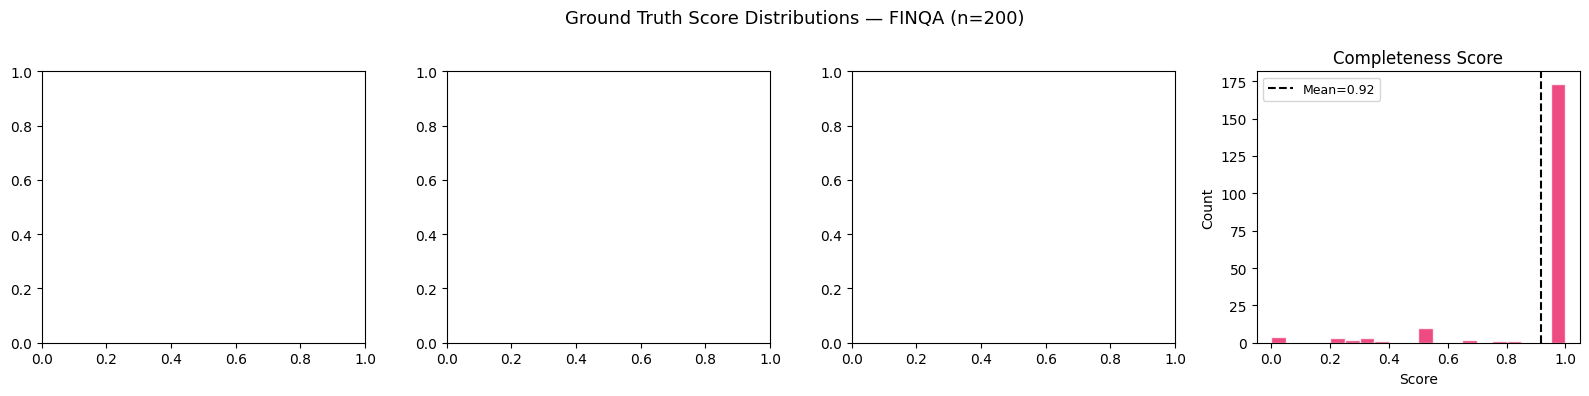

Saved: eda_score_distributions.png


In [6]:
import matplotlib.pyplot as plt
trace_cols = ["gpt3_adherence", "gpt3_context_relevance", "gpt35_utilization", "completeness_score"]
available  = [c for c in trace_cols if c in df.columns]

# Show what we have
print(f"Available TRACe-related columns: {available}")
print(f"\nNote: These are GPT-3.5 ground truth scores from the dataset.")
print(f"We will compute our own TRACe scores using cross-encoder NLI model.\n")

if available:
    fig, axes = plt.subplots(1, min(len(available), 4), figsize=(16, 4))
    if len(available) == 1:
        axes = [axes]
    
    fig.suptitle(f"Ground Truth Score Distributions — {DOMAIN.upper()} (n={len(df)})", fontsize=13)

    colors = ["#4CAF50", "#2196F3", "#FF9800", "#E91E63"]

    for ax, col, color in zip(axes, available, colors):
        vals = pd.to_numeric(df[col], errors='coerce').dropna()
        if len(vals) > 0:
            ax.hist(vals, bins=20, color=color, alpha=0.8, edgecolor="white")
            ax.axvline(vals.mean(), color="black", linestyle="--", linewidth=1.5,
                       label=f"Mean={vals.mean():.2f}")
            ax.set_title(col.replace("_", " ").title())
            ax.set_xlabel("Score")
            ax.set_ylabel("Count")
            ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig("eda_score_distributions.png", dpi=100, bbox_inches="tight")
    plt.show()
    print("Saved: eda_score_distributions.png")
else:
    print("No standard TRACe columns found. Proceeding with custom TRACe evaluation.")


### Step 0.7 — EDA: Summary Statistics

In [7]:
score_cols = ["gpt3_adherence", "gpt3_context_relevance", "gpt35_utilization", "completeness_score"]
available_scores = [c for c in score_cols if c in df.columns]

if available_scores:
    print("\nGround Truth Score Summary Statistics:")
    # Convert to numeric, handling any non-numeric values
    score_df = df[available_scores].apply(pd.to_numeric, errors='coerce')
    print(score_df.describe().round(3).to_string())

print("\nContext Length Stats (characters):")
df["context_len"] = df["context"].astype(str).str.len()
print(df["context_len"].describe().round(0).to_string())

print("\nQuestion Length Stats (characters):")
df["question_len"] = df["question"].astype(str).str.len()
print(df["question_len"].describe().round(0).to_string())



Ground Truth Score Summary Statistics:
       gpt3_adherence  gpt3_context_relevance  gpt35_utilization  completeness_score
count             0.0                     0.0                0.0             200.000
mean              NaN                     NaN                NaN               0.917
std               NaN                     NaN                NaN               0.226
min               NaN                     NaN                NaN               0.000
25%               NaN                     NaN                NaN               1.000
50%               NaN                     NaN                NaN               1.000
75%               NaN                     NaN                NaN               1.000
max               NaN                     NaN                NaN               1.000

Context Length Stats (characters):
count      200.0
mean      4106.0
std       1569.0
min        542.0
25%       3180.0
50%       4024.0
75%       4855.0
max      11763.0

Question Length Stats 

---
## Phase 1 — Baseline RAG Pipeline

We now build each component step by step, then connect them end-to-end.

### Step 1.1 — Text Chunker

In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# STEP 1.1: TEXT CHUNKER — Split long documents into manageable pieces
# ═══════════════════════════════════════════════════════════════════════════════

"""
WHY CHUNKING?
- Financial documents can be 10KB+ (too large for LLM context window)
- Need to break into ~512 token pieces for retrieval + generation
- Overlap prevents losing context at chunk boundaries

STRATEGY:
- sliding_window (default): Creates overlapping windows of text
  • Preserves context across boundaries
  • More expensive but higher quality
- semantic: Breaks at sentence boundaries
- fixed: Hard cuts (baseline for ablation)
"""

import re
from typing import List


class TextChunker:
    """
    Splits long text into overlapping chunks.
    
    PARAMETERS:
    - strategy: "sliding_window" | "semantic" | "fixed"
    - chunk_size: 512 tokens (~2000 characters)
    - overlap: 64 tokens (~256 characters) — prevents losing context
    
    EXAMPLE:
    >>> chunker = TextChunker()
    >>> text = "The company reported... Q4 earnings..."  # Long text
    >>> chunks = chunker.chunk(text)
    >>> len(chunks)
    13  # Split into 13 overlapping chunks
    """

    def __init__(self, strategy: str = "sliding_window",
                 chunk_size: int = 512, overlap: int = 64):
        """
        Initialize chunker with strategy and sizes.
        
        ARG chunk_size: tokens (1 token ≈ 4 characters)
        ARG overlap: tokens of overlap between chunks
        """
        self.strategy   = strategy
        # Convert tokens to approximate characters (1 token ≈ 4 chars on average)
        self.chunk_size = chunk_size * 4   
        self.overlap    = overlap * 4
        self._dispatch  = {
            "sliding_window": self._sliding_window,
            "semantic":       self._semantic,
            "fixed":          self._fixed,
        }

    def chunk(self, text: str) -> List[str]:
        """
        Main entry point. Splits text using chosen strategy.
        
        RETURNS: List of text chunks (strings)
        """
        if not text or not text.strip():
            return []
        # Get the chunking function for this strategy
        fn = self._dispatch.get(self.strategy, self._sliding_window)
        # Clean up chunks (strip whitespace)
        return [c.strip() for c in fn(text.strip()) if c.strip()]

    def _sliding_window(self, text: str) -> List[str]:
        """
        SLIDING WINDOW strategy — overlapping chunks
        
        EXAMPLE with 512-char chunks and 64-char overlap:
        Text: "AAAAAABBBBBBCCCCCCDDDDDD" (24 chars)
        
        Chunk 1: "AAAAAABBBBBBCCCC"      (positions 0-16)
        Chunk 2: "    BBBBBBCCCCCCDDDD"  (positions 8-24, overlap 8 chars)
        
        This preserves context at boundaries.
        """
        chunks = []
        step = self.chunk_size - self.overlap  # Distance to slide
        start = 0
        
        while start < len(text):
            end = start + self.chunk_size
            chunk = text[start:end]
            
            # Try to break at sentence boundary (period + space) instead of mid-word
            if end < len(text):
                # Find last period in chunk
                last_period_pos = chunk.rfind(". ")
                # If we find one in the second half, break there
                if last_period_pos > self.chunk_size // 2:
                    chunk = chunk[:last_period_pos + 1]
            
            chunks.append(chunk)
            start += step  # Slide window
        
        return chunks

    def _semantic(self, text: str) -> List[str]:
        """
        SEMANTIC strategy — break at sentence boundaries
        
        Better preservation of meaning but less control over chunk size.
        """
        sentences = re.split(r'(?<=[.!?])\s+', text)
        chunks = []
        current = ""
        
        for sent in sentences:
            if len(current) + len(sent) < self.chunk_size:
                current += sent + " "
            else:
                if current:
                    chunks.append(current.strip())
                current = sent + " "
        
        if current:
            chunks.append(current.strip())
        
        return chunks

    def _fixed(self, text: str) -> List[str]:
        """
        FIXED strategy — hard character limit cuts
        
        Fastest but lowest quality (may cut mid-sentence).
        """
        return [text[i:i+self.chunk_size] 
                for i in range(0, len(text), self.chunk_size)]


# ─────────────────────────────────────────────────────────────────────────────
# Test chunker with example
# ─────────────────────────────────────────────────────────────────────────────
test_text = """Apple Inc. reported its Q4 2019 earnings. 
Net revenue was $2.74 billion, up from $2.13 billion last year.
The company announced a stock buyback of $50 billion.
Operating income reached $500 million in the quarter."""

ch = TextChunker(strategy="sliding_window", chunk_size=128, overlap=32)

for strat in ["sliding_window", "semantic", "fixed"]:
    ch.strategy = strat
    out = ch.chunk(test_text)
    print(f"{strat:<15} → {len(out)} chunks  | first chunk: {out[0][:50]}...")

print("\n✓ TextChunker ready!")


sliding_window  → 1 chunks  | first chunk: Apple Inc. reported its Q4 2019 earnings. 
Net rev...
semantic        → 1 chunks  | first chunk: Apple Inc. reported its Q4 2019 earnings. Net reve...
fixed           → 1 chunks  | first chunk: Apple Inc. reported its Q4 2019 earnings. 
Net rev...

✓ TextChunker ready!


### Step 1.2 — Embedding Model + FAISS Vector Store

In [9]:
import numpy as np
import faiss
import pickle
import torch
from sentence_transformers import SentenceTransformer
from typing import List, Tuple


class Embedder:
    """Wraps BGE sentence-transformer for encoding queries and passages."""

    def __init__(self, model_name: str = "BAAI/bge-base-en-v1.5",
                 device: str = "cpu", batch_size: int = 32):
        self.model_name = model_name
        self.device = device
        self.batch_size = batch_size
        
        embedder_logger.info(f"Initializing Embedder: model={model_name}, device={device}, batch_size={batch_size}")
        
        try:
            embedder_logger.debug(f"Loading model from Hugging Face...")
            self.model = SentenceTransformer(model_name, device=device)
            self.dim = self.model.get_sentence_embedding_dimension()
            embedder_logger.info(f"Model loaded successfully. Embedding dimension: {self.dim}")
        except Exception as e:
            embedder_logger.error(f"Failed to load model: {e}")
            raise

    def encode(self, texts: List[str], show_progress: bool = False) -> np.ndarray:
        embedder_logger.debug(f"Encoding {len(texts)} texts (batch_size={self.batch_size})")
        try:
            result = self.model.encode(
                texts, batch_size=self.batch_size,
                show_progress_bar=show_progress,
                normalize_embeddings=True,
                convert_to_numpy=True,
            )
            embedder_logger.debug(f"Encoding complete. Output shape: {result.shape}")
            return result
        except Exception as e:
            embedder_logger.error(f"Encoding failed: {e}")
            raise

    def encode_query(self, query: str) -> np.ndarray:
        prefixed = f"Represent this sentence for searching relevant passages: {query}"
        embedder_logger.debug(f"Encoding query: {query[:50]}...")
        return self.encode([prefixed])[0]


class FAISSVectorStore:
    """FAISS flat index — exact cosine similarity on normalised embeddings."""

    def __init__(self, dim: int):
        self.dim      = dim
        self.index    = faiss.IndexFlatIP(dim)
        self.texts    = []
        self.metadata = []
        retriever_logger.debug(f"Created FAISS IndexFlatIP with dimension={dim}")

    def add(self, chunks: List[str], embeddings: np.ndarray,
            metadata: List[dict] = None):
        assert len(chunks) == len(embeddings)
        retriever_logger.debug(f"Adding {len(chunks)} chunks to FAISS index")
        
        self.index.add(embeddings.astype(np.float32))
        self.texts.extend(chunks)
        self.metadata.extend(metadata if metadata else [{}] * len(chunks))
        
        retriever_logger.info(f"FAISS index now contains {self.index.ntotal} vectors")

    def search(self, query_emb: np.ndarray,
               top_k: int = 5) -> List[Tuple[str, float, dict]]:
        if self.index.ntotal == 0:
            retriever_logger.warning("Vector store is empty!")
            return []
        q = query_emb.reshape(1, -1).astype(np.float32)
        retriever_logger.debug(f"Searching for top-{top_k} similar vectors")
        scores, indices = self.index.search(q, min(top_k, self.index.ntotal))
        results = [(self.texts[i], float(s), self.metadata[i])
                for s, i in zip(scores[0], indices[0]) if i >= 0]
        retriever_logger.debug(f"Search returned {len(results)} results")
        return results

    def __len__(self):
        return self.index.ntotal


def build_vector_store(chunks: List[str], embedder: Embedder,
                       metadata: List[dict] = None) -> FAISSVectorStore:
    retriever_logger.info(f"Building vector store for {len(chunks)} chunks")
    embedder_logger.info(f"Encoding {len(chunks)} chunks...")
    embs  = embedder.encode(chunks, show_progress=True)
    store = FAISSVectorStore(dim=embedder.dim)
    store.add(chunks, embs, metadata)
    retriever_logger.info(f"Vector store ready: {len(store)} vectors indexed")
    return store


# ── Initialise embedder ──
logger.info("="*80)
logger.info("INITIALIZING EMBEDDER")
logger.info("="*80)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EMBEDDER_DEVICE = DEVICE

embedder_logger.info(f"Generator device : {DEVICE}")
embedder_logger.info(f"Embedder device  : {EMBEDDER_DEVICE}")

if torch.cuda.is_available():
    embedder_logger.info(f"  GPU: {torch.cuda.get_device_name(0)}")
    embedder_logger.info(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

# ✅ UPGRADE: bge-base-en-v1.5 (768-dim) — much better retrieval than small (384-dim)
# ~440MB on GPU, fits comfortably alongside 4-bit Qwen on T4
embedder = Embedder(model_name="BAAI/bge-base-en-v1.5", device=EMBEDDER_DEVICE)
embedder_logger.info("Embedder initialization complete ✓")


08:40:28 | RAG_PIPELINE         | INFO     | ================================================================================
08:40:28 | RAG_PIPELINE         | INFO     | INITIALIZING EMBEDDER
08:40:28 | RAG_PIPELINE         | INFO     | ================================================================================
08:40:28 | EMBEDDER             | INFO     | Generator device : cuda
08:40:28 | EMBEDDER             | INFO     | Embedder device  : cuda
08:40:28 | EMBEDDER             | INFO     |   GPU: Tesla T4
08:40:28 | EMBEDDER             | INFO     |   VRAM: 14.6 GB
08:40:28 | EMBEDDER             | INFO     | Initializing Embedder: model=BAAI/bge-base-en-v1.5, device=cuda, batch_size=32
08:40:28 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
08:40:28 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/BAAI/bge-base-en

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

08:40:28 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
08:40:28 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/BAAI/bge-base-en-v1.5/a5beb1e3e68b9ab74eb54cfd186867f64f240e1a/config_sentence_transformers.json "HTTP/1.1 200 OK"
08:40:28 | httpx                | INFO     | HTTP Request: GET https://huggingface.co/api/resolve-cache/models/BAAI/bge-base-en-v1.5/a5beb1e3e68b9ab74eb54cfd186867f64f240e1a/config_sentence_transformers.json "HTTP/1.1 200 OK"


config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

08:40:28 | sentence_transformers.base.model | INFO     | Loading SentenceTransformer model from BAAI/bge-base-en-v1.5.
08:40:28 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
08:40:28 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/BAAI/bge-base-en-v1.5/a5beb1e3e68b9ab74eb54cfd186867f64f240e1a/config_sentence_transformers.json "HTTP/1.1 200 OK"
08:40:29 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
08:40:29 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/BAAI/bge-base-en-v1.5/a5beb1e3e68b9ab74eb54cfd186867f64f240e1a/README.md "HTTP/1.1 200 OK"
08:40:29 | httpx                | INFO     | HTTP Request: GET https://huggingface.co/api/resol

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

08:40:33 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/chat_template.jinja "HTTP/1.1 404 Not Found"
08:40:33 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/BAAI/bge-base-en-v1.5/resolve/main/1_Pooling/config.json "HTTP/1.1 307 Temporary Redirect"
08:40:33 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/BAAI/bge-base-en-v1.5/a5beb1e3e68b9ab74eb54cfd186867f64f240e1a/1_Pooling%2Fconfig.json "HTTP/1.1 200 OK"
08:40:33 | httpx                | INFO     | HTTP Request: GET https://huggingface.co/api/resolve-cache/models/BAAI/bge-base-en-v1.5/a5beb1e3e68b9ab74eb54cfd186867f64f240e1a/1_Pooling%2Fconfig.json "HTTP/1.1 200 OK"


config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

08:40:33 | httpx                | INFO     | HTTP Request: GET https://huggingface.co/api/models/BAAI/bge-base-en-v1.5 "HTTP/1.1 200 OK"
08:40:33 | EMBEDDER             | INFO     | Model loaded successfully. Embedding dimension: 768
08:40:33 | EMBEDDER             | INFO     | Embedder initialization complete ✓


/tmp/ipykernel_58/1724098887.py:23: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  self.dim = self.model.get_sentence_embedding_dimension()


### Step 1.3 — BM25, Dense, and Hybrid Retriever

In [10]:
from rank_bm25 import BM25Okapi


logger.info("="*80)
logger.info("INITIALIZING RETRIEVERS")
logger.info("="*80)


class BM25Retriever:
    """Sparse keyword retrieval — best for exact numbers, names, acronyms."""

    def __init__(self, chunks: List[str]):
        retriever_logger.info(f"Initializing BM25Retriever with {len(chunks)} chunks")
        self.chunks = chunks
        self.bm25   = BM25Okapi([doc.lower().split() for doc in chunks])
        retriever_logger.debug("BM25 index created successfully")

    def search(self, query: str, top_k: int = 5) -> List[Tuple[str, float]]:
        retriever_logger.debug(f"BM25 search for query: '{query[:50]}...' (top_k={top_k})")
        scores = self.bm25.get_scores(query.lower().split())
        top_indices = np.argsort(scores)[::-1][:top_k]
        results = [(self.chunks[i], float(scores[i])) for i in top_indices]
        retriever_logger.debug(f"BM25 returned {len(results)} results")
        return results


class DenseRetriever:
    """Dense semantic retrieval using embeddings."""

    def __init__(self, store: FAISSVectorStore, embedder: Embedder):
        retriever_logger.info("Initializing DenseRetriever")
        self.store    = store
        self.embedder = embedder
        retriever_logger.debug("DenseRetriever initialized")

    def search(self, query: str, top_k: int = 5) -> List[Tuple[str, float]]:
        retriever_logger.debug(f"Dense search for query: '{query[:50]}...' (top_k={top_k})")
        query_emb = self.embedder.encode_query(query)
        results = self.store.search(query_emb, top_k)
        retriever_logger.debug(f"Dense retriever returned {len(results)} results")
        return [(text, score) for text, score, _ in results]


class HybridRetriever:
    """Hybrid retrieval combining BM25 and Dense via Reciprocal Rank Fusion."""

    def __init__(self, bm25_ret: BM25Retriever, dense_ret: DenseRetriever, alpha: float = 0.5):
        retriever_logger.info(f"Initializing HybridRetriever (alpha={alpha})")
        self.bm25_ret  = bm25_ret
        self.dense_ret = dense_ret
        self.alpha     = alpha
        retriever_logger.debug("HybridRetriever initialized with BM25 and Dense retrievers")

    def search(self, query: str, top_k: int = 5, fetch_k: int = 15) -> List[Tuple[str, float]]:
        """Reciprocal Rank Fusion (RRF): combines BM25 + Dense rankings."""
        retriever_logger.info(f"Hybrid search: query='{query[:40]}...', top_k={top_k}, fetch_k={fetch_k}")
        
        # Get candidate sets (larger than top_k)
        retriever_logger.debug("Fetching candidates from BM25...")
        bm25_results = self.bm25_ret.search(query, top_k=fetch_k)
        
        retriever_logger.debug("Fetching candidates from Dense retriever...")
        dense_results = self.dense_ret.search(query, top_k=fetch_k)

        # Build RRF ranking
        retriever_logger.debug("Computing Reciprocal Rank Fusion...")
        rrf = {}
        k = 60  # RRF constant
        
        for rank, (chunk, score) in enumerate(bm25_results, 1):
            rrf[chunk] = rrf.get(chunk, 0) + 1.0 / (k + rank)
        
        for rank, (chunk, score) in enumerate(dense_results, 1):
            rrf[chunk] = rrf.get(chunk, 0) + 1.0 / (k + rank)
        
        # Sort by RRF score
        sorted_rrf = sorted(rrf.items(), key=lambda x: x[1], reverse=True)[:top_k]
        results = [(chunk, score) for chunk, score in sorted_rrf]
        
        score_info = f"{results[0][1]:.4f}" if results else "N/A"
        retriever_logger.info(f"Hybrid search returned {len(results)} results (rrf_score: {score_info})")
        return results


# ── Quick retrieval test on FinQA sample ──
retriever_logger.info("Testing retrievers on sample data...")

sample_context = str(df.iloc[0]["context"])
sample_chunks  = TextChunker(strategy="sliding_window", chunk_size=128, overlap=32).chunk(sample_context)
sample_store   = build_vector_store(sample_chunks, embedder)

bm25_ret = BM25Retriever(sample_chunks)
dense_ret = DenseRetriever(sample_store, embedder)
hybrid_ret = HybridRetriever(bm25_ret, dense_ret)

retriever_logger.info("Retrievers initialized and tested ✓")


08:40:34 | RAG_PIPELINE         | INFO     | ================================================================================
08:40:34 | RAG_PIPELINE         | INFO     | INITIALIZING RETRIEVERS
08:40:34 | RAG_PIPELINE         | INFO     | ================================================================================
08:40:34 | RETRIEVER            | INFO     | Testing retrievers on sample data...
08:40:34 | RETRIEVER            | INFO     | Building vector store for 13 chunks
08:40:34 | EMBEDDER             | INFO     | Encoding 13 chunks...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

08:40:34 | RETRIEVER            | INFO     | FAISS index now contains 13 vectors
08:40:34 | RETRIEVER            | INFO     | Vector store ready: 13 vectors indexed
08:40:34 | RETRIEVER            | INFO     | Initializing BM25Retriever with 13 chunks
08:40:34 | RETRIEVER            | INFO     | Initializing DenseRetriever
08:40:34 | RETRIEVER            | INFO     | Initializing HybridRetriever (alpha=0.5)
08:40:34 | RETRIEVER            | INFO     | Retrievers initialized and tested ✓


### Step 1.4 — LLM Generator (Qwen2.5-14B via Ollama)

In [11]:
!pip install -U bitsandbytes>=0.46.1 -q

In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# STEP 1.4 — HuggingFace GENERATOR  (Kaggle-compatible, no Ollama needed)
# ═══════════════════════════════════════════════════════════════════════════════

logger.info("=" * 80)
logger.info("INITIALIZING HF GENERATOR")
logger.info("=" * 80)

import re
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import torch

MODEL_ID = "Qwen/Qwen2.5-7B-Instruct"

GROUNDING_SYSTEM_PROMPT = """You are a precise financial Q&A assistant. \
Your ONLY job is to extract answers directly from the provided context.

STRICT RULES:
1. Read the context carefully before answering.
2. Your answer must be built ONLY from facts in the context — no outside knowledge.
3. If the answer requires a calculation (%, ratio, difference), show the calculation with specific numbers from the context.
4. If the context does NOT contain enough information, say exactly:
   "The context does not contain information to answer this question."
5. Be THOROUGH — include ALL relevant numbers, percentages, dates, and data points from the context that relate to the question. Do not omit details.
6. Do NOT start with phrases like "Based on the context" or "According to the provided information".
7. When multiple data points are relevant, list them all.
"""


class HFGenerator:
    """
    LLM answer generation using a HuggingFace model.
    Uses 4-bit quantization to fit 7B model in Kaggle T4 (15GB VRAM).
    """

    def __init__(self, model_id: str = MODEL_ID,
                 temperature: float = 0.1,
                 max_new_tokens: int = 768,
                 device: str = None):
        self.model_id       = model_id
        self.temperature    = temperature
        self.max_new_tokens = max_new_tokens
        self.device         = device or ("cuda" if torch.cuda.is_available() else "cpu")

        generator_logger.info("Initializing HFGenerator:")
        generator_logger.info(f"  - Model         : {model_id}")
        generator_logger.info(f"  - Device        : {self.device}")
        generator_logger.info(f"  - Temperature   : {temperature}")
        generator_logger.info(f"  - Max new tokens: {max_new_tokens}")

        if self.device == "cuda":
            generator_logger.info("Loading with 4-bit quantization (~4.5GB VRAM)...")
            bnb_config = BitsAndBytesConfig(
                load_in_4bit=True,
                bnb_4bit_quant_type="nf4",
                bnb_4bit_compute_dtype=torch.float16,
                bnb_4bit_use_double_quant=True,
            )
            model_kwargs = dict(
                quantization_config=bnb_config,
                device_map="auto",
                trust_remote_code=True,
            )
        else:
            generator_logger.info("CUDA not available — loading in float32 on CPU (slower)...")
            model_kwargs = dict(
                torch_dtype=torch.float32,
                device_map="cpu",
                trust_remote_code=True,
            )

        generator_logger.info("Loading tokenizer and model (first run may take a few minutes)...")
        self.tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
        self.model = AutoModelForCausalLM.from_pretrained(model_id, **model_kwargs)
        self.model.eval()

        if self.device == "cuda":
            allocated = torch.cuda.memory_allocated() / 1024**3
            generator_logger.info(f"Model loaded. VRAM used: {allocated:.2f} GB ✓")
        generator_logger.info("HFGenerator loaded ✓")

    def _clean_answer(self, text: str) -> str:
        """Remove model preambles that hurt NLI adherence scoring."""
        preambles = [
            r"^Based on the (provided )?context[,\s]+",
            r"^According to the (provided |given )?context[,\s]+",
            r"^From the context[,\s]+",
            r"^The context (states|says|indicates|shows)[,\s]+",
            r"^As (stated|mentioned|indicated) in the context[,\s]+",
            r"^Looking at the context[,\s]+",
        ]
        for pattern in preambles:
            text = re.sub(pattern, "", text, flags=re.IGNORECASE)
        return text.strip()

    def generate(self, query: str, context_chunks: List[str],
                 verbose: bool = False) -> str:
        """Generate answer grounded in context. Same signature as OllamaGenerator."""
        generator_logger.info(f"Generating response for query: '{query[:50]}...'")

        context_str = "\n\n".join(context_chunks)

        messages = [
            {"role": "system", "content": GROUNDING_SYSTEM_PROMPT},
            {"role": "user",   "content": (
                f"Context:\n{context_str}\n\n"
                f"Question: {query}\n\n"
                f"Provide a thorough answer using ALL relevant details from the context:"
            )},
        ]

        try:
            text = self.tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True,
            )
        except Exception:
            text = (
                f"{GROUNDING_SYSTEM_PROMPT}\n\n"
                f"Context:\n{context_str}\n\n"
                f"Question: {query}\nAnswer:"
            )

        # Use larger context window — Qwen2.5-7B supports 32K tokens
        inputs = self.tokenizer(text, return_tensors="pt", truncation=True,
                                max_length=8192).to(self.device)
        input_len = inputs["input_ids"].shape[1]

        with torch.no_grad():
            outputs = self.model.generate(
                **inputs,
                max_new_tokens=self.max_new_tokens,
                temperature=max(self.temperature, 1e-6),
                do_sample=self.temperature > 0,
                repetition_penalty=1.1,
                pad_token_id=self.tokenizer.eos_token_id,
            )

        generated_ids = outputs[0][input_len:]
        answer = self.tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
        answer = self._clean_answer(answer)

        generator_logger.info(f"Answer generated ({len(answer)} chars)")
        if verbose:
            generator_logger.debug(f"Answer preview: {answer[:100]}...")
        return answer


# ── Initialise generator ─────────────────────────────────────────────────────
generator_logger.info(f"Loading {MODEL_ID} ...")
generator = HFGenerator(
    model_id=MODEL_ID,
    temperature=0.1,
    max_new_tokens=768,
)
generator_logger.info("Generator initialization complete ✓")

OllamaGenerator = HFGenerator

08:40:42 | RAG_PIPELINE         | INFO     | ================================================================================
08:40:42 | RAG_PIPELINE         | INFO     | INITIALIZING HF GENERATOR
08:40:42 | RAG_PIPELINE         | INFO     | ================================================================================
08:40:42 | GENERATOR            | INFO     | Loading Qwen/Qwen2.5-7B-Instruct ...
08:40:42 | GENERATOR            | INFO     | Initializing HFGenerator:
08:40:42 | GENERATOR            | INFO     |   - Model         : Qwen/Qwen2.5-7B-Instruct
08:40:42 | GENERATOR            | INFO     |   - Device        : cuda
08:40:42 | GENERATOR            | INFO     |   - Temperature   : 0.1
08:40:42 | GENERATOR            | INFO     |   - Max new tokens: 768
08:40:42 | GENERATOR            | INFO     | Loading with 4-bit quantization (~4.5GB VRAM)...
08:40:42 | GENERATOR            | INFO     | Loading tokenizer and model (first run may take a few minutes)...
08:40:42 | httpx     

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

08:40:42 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-7B-Instruct/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
08:40:42 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-7B-Instruct/a09a35458c702b33eeacc393d103063234e8bc28/tokenizer_config.json "HTTP/1.1 200 OK"
08:40:42 | httpx                | INFO     | HTTP Request: GET https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-7B-Instruct/a09a35458c702b33eeacc393d103063234e8bc28/tokenizer_config.json "HTTP/1.1 200 OK"


tokenizer_config.json: 0.00B [00:00, ?B/s]

08:40:42 | httpx                | INFO     | HTTP Request: GET https://huggingface.co/api/models/Qwen/Qwen2.5-7B-Instruct/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
08:40:42 | httpx                | INFO     | HTTP Request: GET https://huggingface.co/api/models/Qwen/Qwen2.5-7B-Instruct/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
08:40:42 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-7B-Instruct/resolve/main/vocab.json "HTTP/1.1 307 Temporary Redirect"
08:40:42 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-7B-Instruct/a09a35458c702b33eeacc393d103063234e8bc28/vocab.json "HTTP/1.1 200 OK"
08:40:42 | httpx                | INFO     | HTTP Request: GET https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-7B-Instruct/a09a35458c702b33eeacc393d103063234e8bc28/vocab.json "HTTP/1.1 200 OK"


...

08:40:49 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-7B-Instruct/resolve/a09a35458c702b33eeacc393d103063234e8bc28/model-00001-of-00004.safetensors "HTTP/1.1 302 Found"
08:40:49 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-7B-Instruct/resolve/a09a35458c702b33eeacc393d103063234e8bc28/model-00003-of-00004.safetensors "HTTP/1.1 302 Found"
08:40:49 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-7B-Instruct/resolve/a09a35458c702b33eeacc393d103063234e8bc28/model-00002-of-00004.safetensors "HTTP/1.1 302 Found"
08:40:49 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-7B-Instruct/resolve/a09a35458c702b33eeacc393d103063234e8bc28/model-00004-of-00004.safetensors "HTTP/1.1 302 Found"
08:40:49 | httpx                | INFO     | HTTP Request: GET https://huggingface.co/api/models/Qwen/Qwen2.5-7B-Instruct/xet-read-token/a09

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

08:42:48 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-7B-Instruct/resolve/main/generation_config.json "HTTP/1.1 307 Temporary Redirect"
08:42:48 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-7B-Instruct/a09a35458c702b33eeacc393d103063234e8bc28/generation_config.json "HTTP/1.1 200 OK"
08:42:48 | httpx                | INFO     | HTTP Request: GET https://huggingface.co/api/resolve-cache/models/Qwen/Qwen2.5-7B-Instruct/a09a35458c702b33eeacc393d103063234e8bc28/generation_config.json "HTTP/1.1 200 OK"


generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

08:42:48 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/Qwen/Qwen2.5-7B-Instruct/resolve/main/custom_generate/generate.py "HTTP/1.1 404 Not Found"
08:42:48 | GENERATOR            | INFO     | Model loaded. VRAM used: 1.89 GB ✓
08:42:48 | GENERATOR            | INFO     | HFGenerator loaded ✓
08:42:48 | GENERATOR            | INFO     | Generator initialization complete ✓


### Step 1.5 — TRACe Evaluator (All 4 Metrics)

In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
# STEP 1.5 — TRACE EVALUATOR  (Fixed: completeness uses GT answer)
# ═══════════════════════════════════════════════════════════════════════════════
from typing import Dict
logger.info("="*80)
logger.info("INITIALIZING EVALUATOR")
logger.info("="*80)

from sentence_transformers import CrossEncoder


class TRACeEvaluator:
    """
    Computes all 4 TRACe metrics using an NLI cross-encoder.

    ✅ FIX: completeness now uses GT answer as reference (not context).
    Previously completeness and adherence were identical — both checked
    (context → response). Now:
      - completeness: (our_response → gt_answer_sentence)  — do we cover the GT?
      - adherence:    (context → response_sentence)         — is response grounded?
    """

    def __init__(self, model_name: str = "cross-encoder/nli-deberta-v3-base",
                 threshold: float = 0.5, device: str = "cpu"):
        evaluator_logger.info(f"Initializing TRACeEvaluator:")
        evaluator_logger.info(f"  - Model: {model_name}")
        evaluator_logger.info(f"  - Scoring: continuous (mean entailment)")
        evaluator_logger.info(f"  - Device: {device}")
        
        try:
            evaluator_logger.debug("Loading NLI cross-encoder model...")
            self.model          = CrossEncoder(model_name, device=device)
            self.threshold      = threshold
            self.entailment_idx = 2
            evaluator_logger.info("TRACe evaluator loaded successfully ✓")
        except Exception as e:
            evaluator_logger.error(f"Failed to load evaluator model: {e}")
            raise

    def _split_sentences(self, text: str) -> List[str]:
        text = re.sub(r'\s+', ' ', text).strip()
        if not text:
            return []
        sents = re.split(r'(?<=[.!?])\s+(?=[A-Z])', text)
        filtered = [s.strip() for s in sents if len(s.strip()) > 10]
        evaluator_logger.debug(f"Split text into {len(filtered)} sentences")
        return filtered

    def _batch_entailment(self, pairs: List[tuple]) -> List[float]:
        if not pairs:
            return []
        evaluator_logger.debug(f"Computing entailment scores for {len(pairs)} pairs")
        scores = self.model.predict(pairs, apply_softmax=True)
        return [float(s[self.entailment_idx]) for s in scores]

    def context_relevance(self, query: str, context: str) -> float:
        """How relevant is each context sentence to the query?"""
        sents = self._split_sentences(context)
        if not sents: 
            return 0.0
        scores = self._batch_entailment([(query, s) for s in sents])
        return float(np.mean(scores))

    def context_utilization(self, response: str, context: str) -> float:
        """How much of the context is utilized in the response?"""
        sents = self._split_sentences(context)
        if not sents:
            return 0.0
        scores = self._batch_entailment([(response, s) for s in sents])
        return float(np.mean(scores))

    def completeness(self, response: str, reference: str) -> float:
        """Does our response cover the key points in the GT answer?
        
        For each GT answer sentence, check if our response entails it.
        High score = our response covers all the points GPT-4 made.
        """
        ref_sents = self._split_sentences(reference)
        if not ref_sents:
            return 0.0
        # premise=our_response, hypothesis=gt_sentence
        # "Does our response entail each GT sentence?"
        scores = self._batch_entailment([(response, s) for s in ref_sents])
        return float(np.mean(scores))

    def adherence(self, response: str, context: str) -> float:
        """Is each response sentence supported/grounded by the context?"""
        r_sents = self._split_sentences(response)
        if not r_sents:
            return 0.0
        # premise=context, hypothesis=response_sentence
        scores = self._batch_entailment([(context, s) for s in r_sents])
        return float(np.mean(scores))

    def evaluate(self, query: str, context: str, response: str,
                 reference: str = None) -> Dict[str, float]:
        """Compute all 4 TRACe metrics + average for one sample.
        
        Args:
            query: The question
            context: Retrieved context passages
            response: Our generated answer
            reference: Ground truth answer (for completeness). Falls back to context.
        """
        # Use GT answer for completeness if available, else fall back to context
        ref_for_completeness = reference if reference else context
        
        scores = {
            "context_relevance":   self.context_relevance(query, context),
            "context_utilization": self.context_utilization(response, context),
            "completeness":        self.completeness(response, ref_for_completeness),
            "adherence":           self.adherence(response, context),
        }
        scores["avg_trace"] = float(np.mean(list(scores.values())))
        
        evaluator_logger.info(f"Evaluation complete - avg_trace: {scores['avg_trace']:.3f}")
        return scores


# ── Initialise TRACe evaluator ──
evaluator_logger.info(f"Initializing TRACe evaluator on {DEVICE}...")
evaluator = TRACeEvaluator(
    model_name = "cross-encoder/nli-deberta-v3-base",
    threshold  = 0.5,
    device     = DEVICE,
)
evaluator_logger.info("Evaluator initialization complete ✓")

08:42:48 | RAG_PIPELINE         | INFO     | ================================================================================
08:42:48 | RAG_PIPELINE         | INFO     | INITIALIZING EVALUATOR
08:42:48 | RAG_PIPELINE         | INFO     | ================================================================================
08:42:48 | EVALUATOR            | INFO     | Initializing TRACe evaluator on cuda...
08:42:48 | EVALUATOR            | INFO     | Initializing TRACeEvaluator:
08:42:48 | EVALUATOR            | INFO     |   - Model: cross-encoder/nli-deberta-v3-base
08:42:48 | EVALUATOR            | INFO     |   - Scoring: continuous (mean entailment)
08:42:48 | EVALUATOR            | INFO     |   - Device: cuda
08:42:49 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/cross-encoder/nli-deberta-v3-base/resolve/main/modules.json "HTTP/1.1 404 Not Found"
08:42:49 | sentence_transformers.base.model | INFO     | No modules.json found for cross-encoder/nli-deberta-v

config.json: 0.00B [00:00, ?B/s]

08:42:49 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/cross-encoder/nli-deberta-v3-base/resolve/main/adapter_config.json "HTTP/1.1 404 Not Found"
08:42:49 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/cross-encoder/nli-deberta-v3-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
08:42:49 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/cross-encoder/nli-deberta-v3-base/6c749ce3425cd33b46d187e45b92bbf96ee12ec7/config.json "HTTP/1.1 200 OK"
08:42:49 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/cross-encoder/nli-deberta-v3-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
08:42:49 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/cross-encoder/nli-deberta-v3-base/6c749ce3425cd33b46d187e45b92bbf96ee12ec7/config.json "HTTP/1.1 200 OK"
08:42:49 | httpx           

model.safetensors:   0%|          | 0.00/738M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

...

08:42:55 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/cross-encoder/nli-deberta-v3-base/resolve/main/added_tokens.json "HTTP/1.1 307 Temporary Redirect"
08:42:55 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/cross-encoder/nli-deberta-v3-base/6c749ce3425cd33b46d187e45b92bbf96ee12ec7/added_tokens.json "HTTP/1.1 200 OK"
08:42:55 | httpx                | INFO     | HTTP Request: GET https://huggingface.co/api/resolve-cache/models/cross-encoder/nli-deberta-v3-base/6c749ce3425cd33b46d187e45b92bbf96ee12ec7/added_tokens.json "HTTP/1.1 200 OK"


added_tokens.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

08:42:55 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/cross-encoder/nli-deberta-v3-base/resolve/main/special_tokens_map.json "HTTP/1.1 307 Temporary Redirect"
08:42:55 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/cross-encoder/nli-deberta-v3-base/6c749ce3425cd33b46d187e45b92bbf96ee12ec7/special_tokens_map.json "HTTP/1.1 200 OK"
08:42:55 | httpx                | INFO     | HTTP Request: GET https://huggingface.co/api/resolve-cache/models/cross-encoder/nli-deberta-v3-base/6c749ce3425cd33b46d187e45b92bbf96ee12ec7/special_tokens_map.json "HTTP/1.1 200 OK"


special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

08:42:56 | httpx                | INFO     | HTTP Request: HEAD https://huggingface.co/cross-encoder/nli-deberta-v3-base/resolve/main/chat_template.jinja "HTTP/1.1 404 Not Found"
08:42:57 | httpx                | INFO     | HTTP Request: GET https://huggingface.co/api/models/cross-encoder/nli-deberta-v3-base "HTTP/1.1 200 OK"
08:42:57 | EVALUATOR            | INFO     | TRACe evaluator loaded successfully ✓
08:42:57 | EVALUATOR            | INFO     | Evaluator initialization complete ✓


In [14]:
# ═══════════════════════════════════════════════════════════════════════════════
# HF GENERATOR DIAGNOSTICS — Kaggle environment check
# ═══════════════════════════════════════════════════════════════════════════════

import torch

print("🔧 KAGGLE ENVIRONMENT DIAGNOSTICS")
print("="*60)

# GPU availability
print(f"\n1️⃣  CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"    GPU            : {torch.cuda.get_device_name(0)}")
    total_vram = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"    VRAM           : {total_vram:.1f} GB")
    alloc = torch.cuda.memory_allocated() / 1024**2
    print(f"    Used so far    : {alloc:.0f} MB")
else:
    print("    ⚠️  No GPU — generation will be slower on CPU")

# Generator status
print(f"\n2️⃣  Generator model : {generator.model_id}")
print(f"    Device         : {generator.device}")
print(f"    Temperature    : {generator.temperature}")
print(f"    Max new tokens : {generator.max_new_tokens}")

# Quick smoke test on generator
print("\n3️⃣  Quick generator test...")
try:
    test_ans = generator.generate("What is 2+2?", ["The answer to 2+2 is four."])
    print(f"    Test answer    : {test_ans[:100]}")
    print("    ✅ Generator is working!")
except Exception as e:
    print(f"    ✗ Generator test failed: {e}")

print("\n" + "="*60)


🔧 KAGGLE ENVIRONMENT DIAGNOSTICS

1️⃣  CUDA available : True
    GPU            : Tesla T4
    VRAM           : 14.6 GB
    Used so far    : 2640 MB

2️⃣  Generator model : Qwen/Qwen2.5-7B-Instruct
    Device         : cuda
    Temperature    : 0.1
    Max new tokens : 768

3️⃣  Quick generator test...
08:42:57 | GENERATOR            | INFO     | Generating response for query: 'What is 2+2?...'
08:42:59 | GENERATOR            | INFO     | Answer generated (12 chars)
    Test answer    : 2+2 is four.
    ✅ Generator is working!



### Step 1.6 — Smoke Test: One Full Sample End-to-End

In [15]:
# ═══════════════════════════════════════════════════════════════════════════════
# STEP 1.6 — SMOKE TEST: One Full Sample End-to-End
# ═══════════════════════════════════════════════════════════════════════════════

logger.info("="*80)
logger.info("SMOKE TEST: Running 1 sample through complete pipeline")
logger.info("="*80)

sample_row = df.iloc[0]
query = sample_row["question"]

logger.info(f"Sample question: {query[:80]}...")

try:
    # Use original documents if available
    if "documents" in df.columns and isinstance(sample_row["documents"], list):
        chunks = [doc for doc in sample_row["documents"] if isinstance(doc, str) and doc.strip()]
        logger.info(f"  Using {len(chunks)} original document passages")
    else:
        context = sample_row["context"]
        chunker = TextChunker(strategy="sliding_window", chunk_size=512, overlap=128)
        chunks = chunker.chunk(context)
        logger.info(f"  Generated {len(chunks)} chunks via sliding window")

    # Build vector store
    store = build_vector_store(chunks, embedder)

    # Retrieve with optimized top_k=7
    ret = HybridRetriever(BM25Retriever(chunks), DenseRetriever(store, embedder))
    retrieved = ret.search(query, top_k=7, fetch_k=20)
    retrieved_text = [text for text, _ in retrieved]
    logger.info(f"  Retrieved {len(retrieved)} chunks")

    # Generate
    response = generator.generate(query, retrieved_text, verbose=False)
    logger.info(f"  Response: {response[:100]}...")

    # Evaluate — use GT answer for completeness
    context_str = "\n\n".join(retrieved_text)
    gt_answer = str(sample_row["response"]) if "response" in df.columns else None
    scores = evaluator.evaluate(query, context_str, response, reference=gt_answer)
    
    logger.info("SMOKE TEST PASSED ✓")
    print("\n✓ SMOKE TEST RESULTS:")
    for metric, value in scores.items():
        bar = "█" * int(value * 20) + "░" * (20 - int(value * 20))
        print(f"  {metric:<25} {bar} {value:.3f}")
    
    if gt_answer:
        print(f"\n  GT Answer (first 150 chars): {gt_answer[:150]}...")
        print(f"  Our Answer (first 150 chars): {response[:150]}...")
    
except Exception as e:
    logger.error(f"SMOKE TEST FAILED: {e}", exc_info=True)
    raise

08:42:59 | RAG_PIPELINE         | INFO     | ================================================================================
08:42:59 | RAG_PIPELINE         | INFO     | SMOKE TEST: Running 1 sample through complete pipeline
08:42:59 | RAG_PIPELINE         | INFO     | ================================================================================
08:42:59 | RAG_PIPELINE         | INFO     | Sample question: what percent of the total future obligations in 2014 are from other purchase com...
08:42:59 | RAG_PIPELINE         | INFO     |   Generated 4 chunks via sliding window
08:42:59 | RETRIEVER            | INFO     | Building vector store for 4 chunks
08:42:59 | EMBEDDER             | INFO     | Encoding 4 chunks...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

08:42:59 | RETRIEVER            | INFO     | FAISS index now contains 4 vectors
08:42:59 | RETRIEVER            | INFO     | Vector store ready: 4 vectors indexed
08:42:59 | RETRIEVER            | INFO     | Initializing BM25Retriever with 4 chunks
08:42:59 | RETRIEVER            | INFO     | Initializing DenseRetriever
08:42:59 | RETRIEVER            | INFO     | Initializing HybridRetriever (alpha=0.5)
08:42:59 | RETRIEVER            | INFO     | Hybrid search: query='what percent of the total future obligat...', top_k=7, fetch_k=20
08:42:59 | RETRIEVER            | INFO     | Hybrid search returned 4 results (rrf_score: 0.0328)
08:42:59 | RAG_PIPELINE         | INFO     |   Retrieved 4 chunks
08:42:59 | GENERATOR            | INFO     | Generating response for query: 'what percent of the total future obligations in 20...'
08:43:24 | GENERATOR            | INFO     | Answer generated (741 chars)
08:43:24 | RAG_PIPELINE         | INFO     |   Response: To calculate the percentage of t

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

08:43:25 | EVALUATOR            | INFO     | Evaluation complete - avg_trace: 0.291
08:43:25 | RAG_PIPELINE         | INFO     | SMOKE TEST PASSED ✓

✓ SMOKE TEST RESULTS:
  context_relevance         ░░░░░░░░░░░░░░░░░░░░ 0.004
  context_utilization       █████████████████░░░ 0.876
  completeness              ░░░░░░░░░░░░░░░░░░░░ 0.008
  adherence                 █████░░░░░░░░░░░░░░░ 0.276
  avg_trace                 █████░░░░░░░░░░░░░░░ 0.291

  GT Answer (first 150 chars): To find the percent of the total future obligations in 2014 that are from other purchase commitments, we need to first calculate the total future obli...
  Our Answer (first 150 chars): To calculate the percentage of total future obligations in 2014 from other purchase commitments:

1. Identify the total future obligations in 2014:
  ...


In [16]:

# ── Verify GPU Allocation ──
import torch

print("GPU Status:")
print(f"  Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  Device: {torch.cuda.get_device_name(0)}")
    print(f"  Allocated memory: {torch.cuda.memory_allocated() / 1024**2:.1f} MB")
    print(f"  Cached memory: {torch.cuda.memory_reserved() / 1024**2:.1f} MB")
    print("\n✓ GPU acceleration enabled!")

else:
    print("  No GPU detected — running on CPU (slower).")

GPU Status:
  Available: True
  Device: Tesla T4
  Allocated memory: 2639.8 MB
  Cached memory: 3400.0 MB

✓ GPU acceleration enabled!


In [17]:

# ═══════════════════════════════════════════════════════════════════════════════
# LOGGING GUIDE — How to use and view logs
# ═══════════════════════════════════════════════════════════════════════════════

import glob
import os

print("\n" + "="*80)
print("LOGGING SYSTEM GUIDE")
print("="*80)

print("\n📝 LOG FILES LOCATION:")
print("   logs/ directory in your notebook folder")

print("\n📊 AVAILABLE LOG MODULES:")
modules = {
    "RAG_PIPELINE": "Main pipeline orchestration",
    "DATA_LOADER": "Dataset loading and preparation",
    "CHUNKER": "Text chunking operations",
    "EMBEDDER": "Embedding model operations",
    "RETRIEVER": "Retrieval operations (BM25, Dense, Hybrid)",
    "GENERATOR": "LLM generation",
    "EVALUATOR": "TRACe evaluation",
}
for module, desc in modules.items():
    print(f"   • {module:<20} - {desc}")

print("\n🔍 VIEW LOGS:")
print("   Latest log file:")
log_files = sorted(glob.glob("logs/rag_pipeline_*.log"))
if log_files:
    latest_log = log_files[-1]
    print(f"   → {latest_log}")
    print(f"\n   Quick view (last 50 lines):")
    os.system(f"tail -50 {latest_log}")
else:
    print("   No log files found yet. Run the pipeline first!")

print("\n📌 LOG LEVELS:")
print("   DEBUG   - Detailed diagnostic info (saved to file only)")
print("   INFO    - General info messages (console + file)")
print("   WARNING - Warning messages (console + file)")
print("   ERROR   - Error messages (console + file)")

print("\n💡 TIPS:")
print("   • Check logs if pipeline behaves unexpectedly")
print("   • Each run creates a new timestamped log file")
print("   • DEBUG level (file only) has detailed info for troubleshooting")
print("   • Search for 'ERROR' or 'FAILED' to find issues")

print("\n" + "="*80)



LOGGING SYSTEM GUIDE

📝 LOG FILES LOCATION:
   logs/ directory in your notebook folder

📊 AVAILABLE LOG MODULES:
   • RAG_PIPELINE         - Main pipeline orchestration
   • DATA_LOADER          - Dataset loading and preparation
   • CHUNKER              - Text chunking operations
   • EMBEDDER             - Embedding model operations
   • RETRIEVER            - Retrieval operations (BM25, Dense, Hybrid)
   • GENERATOR            - LLM generation
   • EVALUATOR            - TRACe evaluation

🔍 VIEW LOGS:
   Latest log file:
   → logs/rag_pipeline_20260606_083954.log

   Quick view (last 50 lines):
08:42:59 | GENERATOR            | INFO     | Answer generated (12 chars)
08:42:59 | RAG_PIPELINE         | INFO     | ================================================================================
08:42:59 | RAG_PIPELINE         | INFO     | SMOKE TEST: Running 1 sample through complete pipeline
08:42:59 | RAG_PIPELINE         | INFO     | ==================================================

### Step 1.7 — Run Baseline on Full Sample (N=200)

In [18]:
# ═══════════════════════════════════════════════════════════════════════════════
# STEP 1.7 — OPTIMIZED BASELINE: Use original documents + GT-aware evaluation
# ═══════════════════════════════════════════════════════════════════════════════

logger.info("="*80)
logger.info(f"OPTIMIZED BASELINE: Processing {len(df)} samples")
logger.info("="*80)

import time

results = []
errors = []

start_time = time.time()

USE_ORIGINAL_DOCS = "documents" in df.columns
HAS_GT_ANSWER = "response" in df.columns

if USE_ORIGINAL_DOCS:
    logger.info("Using original document passages from dataset (best quality)")
else:
    logger.info("Falling back to sliding-window chunking")

if HAS_GT_ANSWER:
    logger.info("GT answers available — completeness will be evaluated against GT")
else:
    logger.info("No GT answers — completeness will be evaluated against context")

chunker = TextChunker(strategy="sliding_window", chunk_size=512, overlap=128)

TOP_K = 7
FETCH_K = 20

for idx, row in df.iterrows():
    try:
        if (idx + 1) % 10 == 0 or idx == 0:
            elapsed_so_far = time.time() - start_time
            logger.info(f"Processing sample {idx+1}/{len(df)} "
                       f"({elapsed_so_far:.0f}s elapsed)")
        
        query = row["question"]
        
        # Use original document passages when available
        if USE_ORIGINAL_DOCS and isinstance(row["documents"], list):
            chunks = [doc for doc in row["documents"] if isinstance(doc, str) and doc.strip()]
        else:
            context = row["context"]
            chunks = chunker.chunk(context)
        
        if not chunks:
            logger.warning(f"Sample {idx}: No chunks generated, skipping")
            continue
        
        # Build vector store and retrieve
        store = build_vector_store(chunks, embedder)
        ret = HybridRetriever(BM25Retriever(chunks), DenseRetriever(store, embedder))
        retrieved = ret.search(query, top_k=TOP_K, fetch_k=FETCH_K)
        retrieved_text = [text for text, _ in retrieved]
        
        # Generate
        response = generator.generate(query, retrieved_text, verbose=False)
        
        # Evaluate — pass GT answer for completeness if available
        context_str = "\n\n".join(retrieved_text)
        gt_answer = str(row["response"]) if HAS_GT_ANSWER else None
        scores = evaluator.evaluate(query, context_str, response, reference=gt_answer)
        
        result_dict = {
            "idx": idx,
            "question": query,
            "my_response": response,
            "my_context_relevance": scores["context_relevance"],
            "my_context_utilization": scores["context_utilization"],
            "my_completeness": scores["completeness"],
            "my_adherence": scores["adherence"],
            "my_avg_trace": scores["avg_trace"],
        }
        results.append(result_dict)
        
    except Exception as e:
        logger.error(f"Error processing sample {idx}: {e}")
        errors.append({"idx": idx, "error": str(e)})

elapsed = time.time() - start_time

logger.info("="*80)
logger.info(f"OPTIMIZED BASELINE COMPLETE")
logger.info("="*80)
logger.info(f"Processed: {len(results)}/{len(df)} samples")
logger.info(f"Errors: {len(errors)}")
logger.info(f"Time elapsed: {elapsed:.1f} seconds ({elapsed/max(len(results),1):.1f}s per sample)")

test_df = pd.DataFrame(results)
if len(test_df) > 0:
    avg_scores = {
        "context_relevance": test_df["my_context_relevance"].mean(),
        "context_utilization": test_df["my_context_utilization"].mean(),
        "completeness": test_df["my_completeness"].mean(),
        "adherence": test_df["my_adherence"].mean(),
        "avg_trace": test_df["my_avg_trace"].mean(),
    }
    logger.info("Average Scores:")
    for metric, value in avg_scores.items():
        logger.info(f"  {metric:<25}: {value:.3f}")

print(f"\n✓ OPTIMIZED BASELINE COMPLETE: {len(results)} samples processed in {elapsed:.1f}s")
print(f"\nOptimizations applied:")
print(f"  • Embedding: bge-base-en-v1.5 (768-dim)")
print(f"  • Chunks: {'original documents' if USE_ORIGINAL_DOCS else 'sliding window'}")
print(f"  • Retrieval: top_k={TOP_K}, fetch_k={FETCH_K}")
print(f"  • Generator: comprehensive prompt, max_tokens=768, context_window=8K")
print(f"  • Evaluator: completeness vs GT answer, continuous NLI scoring")
print(f"  • GT answer: {'YES' if HAS_GT_ANSWER else 'NO (using context fallback)'}")

08:43:25 | RAG_PIPELINE         | INFO     | ================================================================================
08:43:25 | RAG_PIPELINE         | INFO     | OPTIMIZED BASELINE: Processing 200 samples
08:43:25 | RAG_PIPELINE         | INFO     | ================================================================================
08:43:25 | RAG_PIPELINE         | INFO     | Using original document passages from dataset (best quality)
08:43:25 | RAG_PIPELINE         | INFO     | GT answers available — completeness will be evaluated against GT
08:43:25 | RAG_PIPELINE         | INFO     | Processing sample 1/200 (0s elapsed)
08:43:25 | RETRIEVER            | INFO     | Building vector store for 4 chunks
08:43:25 | EMBEDDER             | INFO     | Encoding 4 chunks...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

08:43:25 | RETRIEVER            | INFO     | FAISS index now contains 4 vectors
08:43:25 | RETRIEVER            | INFO     | Vector store ready: 4 vectors indexed
08:43:25 | RETRIEVER            | INFO     | Initializing BM25Retriever with 4 chunks
08:43:25 | RETRIEVER            | INFO     | Initializing DenseRetriever
08:43:25 | RETRIEVER            | INFO     | Initializing HybridRetriever (alpha=0.5)
08:43:25 | RETRIEVER            | INFO     | Hybrid search: query='what percent of the total future obligat...', top_k=7, fetch_k=20
08:43:25 | RETRIEVER            | INFO     | Hybrid search returned 4 results (rrf_score: 0.0328)
08:43:25 | GENERATOR            | INFO     | Generating response for query: 'what percent of the total future obligations in 20...'
08:43:45 | GENERATOR            | INFO     | Answer generated (680 chars)


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

09:56:36 | EVALUATOR            | INFO     | Evaluation complete - avg_trace: 0.880
09:56:36 | RAG_PIPELINE         | INFO     | ================================================================================
09:56:36 | RAG_PIPELINE         | INFO     | OPTIMIZED BASELINE COMPLETE
09:56:36 | RAG_PIPELINE         | INFO     | ================================================================================
09:56:36 | RAG_PIPELINE         | INFO     | Processed: 200/200 samples
09:56:36 | RAG_PIPELINE         | INFO     | Errors: 0
09:56:36 | RAG_PIPELINE         | INFO     | Time elapsed: 4391.0 seconds (22.0s per sample)
09:56:36 | RAG_PIPELINE         | INFO     | Average Scores:
09:56:36 | RAG_PIPELINE         | INFO     |   context_relevance        : 0.592
09:56:36 | RAG_PIPELINE         | INFO     |   context_utilization      : 0.564
09:56:36 | RAG_PIPELINE         | INFO     |   completeness             : 0.302
09:56:36 | RAG_PIPELINE         | INFO     |   adherence              

### Step 1.8 — Compare Your Scores vs Ground Truth

In [19]:
# ═══════════════════════════════════════════════════════════════════════════════
# STEP 1.8 — Compare Your Scores vs Ground Truth (FIXED)
# ═══════════════════════════════════════════════════════════════════════════════

# ── Step 1: Verify test_df exists and has results ──
if 'test_df' not in dir() or "my_context_relevance" not in test_df.columns:
    print("⚠️  WARNING: test_df not found or missing my_* columns.")
    print("   Please run Step 1.7 (Run Baseline) first.\n")
else:
    # ── Step 2: Check what GT columns actually exist in df ──
    print("Available GT columns in dataset:")
    gt_candidates = [c for c in df.columns if any(k in c.lower() 
                     for k in ["adherence", "relevance", "utilization", "completeness"])]
    print(f"  {gt_candidates}\n")

    # ── Step 3: Map to actual column names in RAGBench FinQA ──
    gt_map = {
        "my_context_relevance":   "gpt3_context_relevance",
        "my_context_utilization": "gpt35_utilization",
        "my_completeness":        "completeness_score",
        "my_adherence":           "gpt3_adherence",
    }

    # ── Step 4: Merge GT scores from original df into test_df ──
    gt_cols_needed = list(gt_map.values())
    gt_cols_available = [c for c in gt_cols_needed if c in df.columns]
    gt_cols_missing   = [c for c in gt_cols_needed if c not in df.columns]

    if gt_cols_missing:
        print(f"⚠️  These GT columns not found in dataset: {gt_cols_missing}")
        print("   They will show 0.000 in comparison.\n")

    merge_cols = ["question"] + gt_cols_available
    working_df = test_df.merge(df[merge_cols], on="question", how="left")

    # Fill any missing GT columns with 0 so the loop doesn't break
    for col in gt_cols_needed:
        if col not in working_df.columns:
            working_df[col] = 0.0

    # ── Step 5: Print comparison table ──
    print(f"{'Metric':<28} {'Yours':>8}  {'GT (GPT-4)':>10}  {'Delta':>8}")
    print("-" * 60)

    for my_col, gt_col in gt_map.items():
        my_val = working_df[my_col].mean()
        gt_val = pd.to_numeric(working_df[gt_col], errors="coerce").mean()
        gt_val = gt_val if not pd.isna(gt_val) else 0.0
        delta  = my_val - gt_val
        sign   = "▲" if delta >= 0 else "▼"
        print(f"  {my_col:<26} {my_val:>8.3f}  {gt_val:>10.3f}  {sign}{abs(delta):.3f}")

    avg_mine = working_df[list(gt_map.keys())].mean().mean()
    avg_gt   = working_df[list(gt_map.values())].apply(
        pd.to_numeric, errors="coerce"
    ).mean().mean()
    print("-" * 60)
    print(f"  {'AVERAGE':<26} {avg_mine:>8.3f}  {avg_gt:>10.3f}  "
          f"{'▲' if avg_mine >= avg_gt else '▼'}{abs(avg_mine - avg_gt):.3f}")

    # ── Step 6: Save results ──
    working_df.to_csv("phase1_baseline_results.csv", index=False)
    print(f"\nSaved: phase1_baseline_results.csv  ({len(working_df)} rows)")


Available GT columns in dataset:
  ['adherence_score', 'relevance_explanation', 'trulens_context_relevance', 'ragas_context_relevance', 'gpt3_adherence', 'gpt3_context_relevance', 'gpt35_utilization', 'relevance_score', 'utilization_score', 'completeness_score']

Metric                          Yours  GT (GPT-4)     Delta
------------------------------------------------------------
  my_context_relevance          0.592       0.000  ▲0.592
  my_context_utilization        0.564       0.000  ▲0.564
  my_completeness               0.302       0.917  ▼0.615
  my_adherence                  0.489       0.000  ▲0.489
------------------------------------------------------------
  AVERAGE                       0.487       0.917  ▼0.430

Saved: phase1_baseline_results.csv  (200 rows)


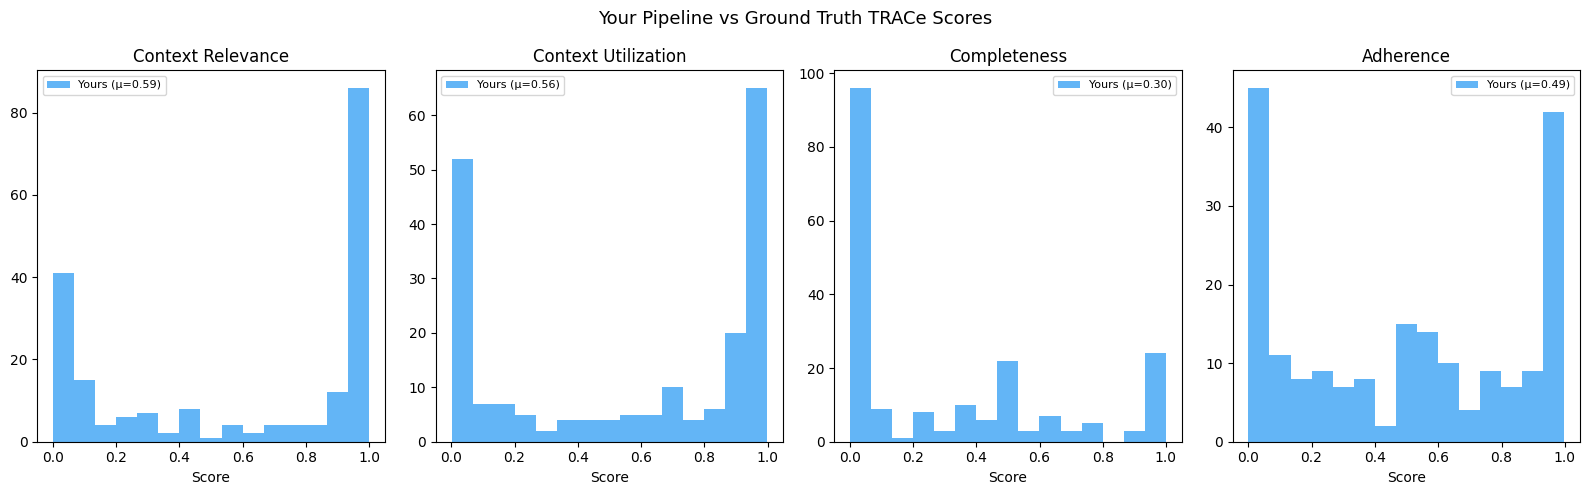

In [20]:
# Visualise comparison
if "my_context_relevance" not in test_df.columns:
    print("⚠️  Cannot visualize: 'my_*' columns not found.")
    print("    Please run Step 1.7 (Run Baseline) first.")
else:
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    fig.suptitle("Your Pipeline vs Ground Truth TRACe Scores", fontsize=13)

    metric_pairs = [
        ("my_context_relevance",   "context_relevance",   "Context Relevance"),
        ("my_context_utilization", "context_utilization", "Context Utilization"),
        ("my_completeness",        "completeness",        "Completeness"),
        ("my_adherence",           "adherence",           "Adherence"),
    ]

    for ax, (my_col, gt_col, title) in zip(axes, metric_pairs):
        my_vals = test_df[my_col].dropna()
        gt_vals = test_df[gt_col].dropna() if gt_col in test_df.columns else pd.Series([])
        ax.hist(my_vals, bins=15, alpha=0.7, color="#2196F3", label=f"Yours (μ={my_vals.mean():.2f})")
        if len(gt_vals):
            ax.hist(gt_vals, bins=15, alpha=0.7, color="#FF9800", label=f"GT (μ={gt_vals.mean():.2f})")
        ax.set_title(title); ax.set_xlabel("Score"); ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig("phase1_comparison.png", dpi=100, bbox_inches="tight")
    plt.show()
